<a href="https://colab.research.google.com/github/joyumoh/Titanic_Survival_Prediction_Model/blob/main/Week5_Advanced_ML_Titanic_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5: Advanced Machine Learning - Titanic Survival Prediction

In previous weeks, I cleaned the Titanic dataset, engineered new features, and built a baseline Logistic Regression model plus a Decision Tree that I pruned to control overfitting. This week, my goal is to go further: build a Decision Tree, Random Forest, and Gradient Boosting model on the same engineered dataset, tune at least one of them, and compare all three on a common set of metrics so I can defend which one I'd actually deploy.



### Importing Librabries
I'm importing everything up front rather than scattering imports through the notebook. This makes it obvious at a glance what tools this project depends on, and it's the convention I'll want to keep for any notebook I hand to a reviewer.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_style("whitegrid")
RANDOM_STATE = 42  # fixing this so every model, split, and search is reproducible

pd.set_option("display.max_columns", None)

### Loading the dataset
I'm loading the same cleaned Titanic file I used in previous weeks.


In [ ]:
df = pd.read_csv("/content/cleaned_titanic.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (891, 24)


,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,TicketGroup,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
0,0,3,22.0,1,0,7.2500,2,0,1,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True
1,1,1,38.0,1,0,71.2833,2,0,1,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,1,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True
3,1,1,35.0,1,0,53.1000,2,0,2,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False
4,0,3,35.0,0,0,8.0500,1,1,1,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   FamilySize   891 non-null    int64  
 7   IsAlone      891 non-null    int64  
 8   TicketGroup  891 non-null    int64  
 9   Sex_male     891 non-null    bool   
 10  Embarked_Q   891 non-null    bool   
 11  Embarked_S   891 non-null    bool   
 12  Title_Miss   891 non-null    bool   
 13  Title_Mr     891 non-null    bool   
 14  Title_Mrs    891 non-null    bool   
 15  Title_Rare   891 non-null    bool   
 16  Deck_B       891 non-null    bool   
 17  Deck_C       891 non-null    bool   
 18  Deck_D       891 non-null    bool   
 19  Deck_E  

### 1.6 Train/test split
I'm splitting 80/20, matching the split I used previously so results stay comparable. I'm using `stratify=y` to make sure the survival rate (roughly 38% survived) is preserved in both the training and test sets - with a class imbalance like this, a random split could accidentally give me a test set with a different survival rate, which would make my evaluation metrics misleading.

In [ ]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"Survival rate - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Training set: 712 rows
Test set: 179 rows
Survival rate — train: 0.383, test: 0.385


I'm also setting up one helper function I'll reuse for every model I train. Instead of copy-pasting the same eight lines of evaluation code four times, I'm writing it once. This keeps the notebook shorter and means if I ever want to change how I measure a model (say, add ROC-AUC), I only change it in one place.

In [ ]:
results = []  # will collect one row per model for the final comparison table

def evaluate_model(name, model, X_train, X_test, y_train, y_test, store=True):
    """Train, time, predict, and score a model. Returns predictions for further inspection."""
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Training Time (s)": round(train_time, 4),
    }

    if store:
        results.append(metrics)

    print(f"--- {name} ---")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v}")
    print()

    return model, y_pred, metrics

## Decision Tree

I'm starting with a Decision Tree as my baseline for this week because it's the simplest model in the lineup and the direct ancestor of Random Forest and Gradient Boosting - both are built from many trees. Seeing how a single tree performs gives me a reference point to judge whether the ensemble methods are actually earning their extra complexity.

I'm capping `max_depth=5` from the start. In Week 3 I found that an unconstrained tree overfits badly (it memorizes the training data instead of learning general patterns), so rather than repeat that mistake, I'm going in with a sensible constraint already applied.

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_model, dt_pred, dt_metrics = evaluate_model(
    "Decision Tree", dt_model, X_train, X_test, y_train, y_test
)

--- Decision Tree ---
Accuracy: 0.776536312849162
Precision: 0.7959183673469388
Recall: 0.5652173913043478
F1-Score: 0.6610169491525424
Training Time (s): 0.0069



## Random Forest

A single tree's predictions depend heavily on exactly which splits it happened to make - small changes in the training data can produce a very different tree. Random Forest addresses this by training many trees, each on a random subset of the data and a random subset of features, then averaging their votes. My expectation is that this reduces variance and should outperform the single tree, at some cost in interpretability and training time.

I'm starting with 100 trees (`n_estimators=100`), which is a reasonable scikit-learn default, before I tune this properly later.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model, rf_pred, rf_metrics = evaluate_model(
    "Random Forest", rf_model, X_train, X_test, y_train, y_test
)

--- Random Forest ---
Accuracy: 0.776536312849162
Precision: 0.7230769230769231
Recall: 0.6811594202898551
F1-Score: 0.7014925373134329
Training Time (s): 0.2712



## Gradient Boosting

Random Forest builds many trees independently and averages them. Gradient Boosting instead builds trees **sequentially**, where each new tree is trained specifically to correct the errors of the ones before it. My expectation going in is that this often produces better accuracy than Random Forest because it's directly targeting mistakes, but it can also be more prone to overfitting and is generally slower to train since the trees can't be built in parallel.

I'm using a conservative `learning_rate=0.1` and `n_estimators=100` as a starting point, matching the Random Forest tree count so the comparison at this stage isn't confounded by using very different model sizes.

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE
)
gb_model, gb_pred, gb_metrics = evaluate_model(
    "Gradient Boosting", gb_model, X_train, X_test, y_train, y_test
)

--- Gradient Boosting ---
Accuracy: 0.7932960893854749
Precision: 0.7758620689655172
Recall: 0.6521739130434783
F1-Score: 0.7086614173228346
Training Time (s): 0.1868



## Hyperparameter Tuning

I'm tuning **both** Random Forest and Gradient Boosting rather than just one, since I want to see whether tuning closes or widens the gap between them.

I'm using `GridSearchCV` with 5-fold stratified cross-validation for both. I chose Grid Search over Random Search here because my parameter grids are small enough (a few dozen combinations) that an exhaustive search is still fast - Random Search earns its keep on larger grids where checking every combination would be too slow. I'm scoring on F1 rather than accuracy because the classes aren't perfectly balanced (~62% did not survive), and F1 forces the search to balance precision and recall rather than just chasing the majority class.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)

start = time.time()
rf_grid.fit(X_train, y_train)
rf_tune_time = time.time() - start

print(f"Best Random Forest params: {rf_grid.best_params_}")
print(f"Best CV F1-score: {rf_grid.best_score_:.4f}")
print(f"Search time: {rf_tune_time:.2f}s")

Best Random Forest params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-score: 0.7785
Search time: 57.70s


In [ ]:
gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=gb_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)

start = time.time()
gb_grid.fit(X_train, y_train)
gb_tune_time = time.time() - start

print(f"Best Gradient Boosting params: {gb_grid.best_params_}")
print(f"Best CV F1-score: {gb_grid.best_score_:.4f}")
print(f"Search time: {gb_tune_time:.2f}s")

Best Gradient Boosting params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 200}
Best CV F1-score: 0.7757
Search time: 29.02s


### Evaluating the tuned models on the test set
The grid search picked the best parameters based on cross-validation performance on the training data. Now I'm checking how those tuned models actually do on the untouched test set - this is the number that matters for the final comparison, not the CV score, since the CV score can be slightly optimistic.

In [ ]:
rf_tuned = rf_grid.best_estimator_
_, rf_tuned_pred, rf_tuned_metrics = evaluate_model(
    "Random Forest (Tuned)", rf_tuned, X_train, X_test, y_train, y_test, store=False
)
rf_tuned_metrics["Training Time (s)"] = round(rf_tune_time, 4)
results.append(rf_tuned_metrics)

--- Random Forest (Tuned) ---
Accuracy: 0.7932960893854749
Precision: 0.7666666666666667
Recall: 0.6666666666666666
F1-Score: 0.7131782945736435
Training Time (s): 0.1236



In [ ]:
gb_tuned = gb_grid.best_estimator_
_, gb_tuned_pred, gb_tuned_metrics = evaluate_model(
    "Gradient Boosting (Tuned)", gb_tuned, X_train, X_test, y_train, y_test, store=False
)
gb_tuned_metrics["Training Time (s)"] = round(gb_tune_time, 4)
results.append(gb_tuned_metrics)

--- Gradient Boosting (Tuned) ---
Accuracy: 0.7932960893854749
Precision: 0.7666666666666667
Recall: 0.6666666666666666
F1-Score: 0.7131782945736435
Training Time (s): 0.2121



## Model Comparison

Now I'm pulling every model's metrics into one table so I can compare them side by side. I'm sorting by F1-Score rather than accuracy, since F1 balances precision and recall and gives a fairer picture than accuracy alone on a dataset that isn't perfectly balanced.

In [ ]:
comparison_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,Gradient Boosting (Tuned),0.793296,0.766667,0.666667,0.713178,29.0219
1,Random Forest (Tuned),0.793296,0.766667,0.666667,0.713178,57.7050
2,Gradient Boosting,0.793296,0.775862,0.652174,0.708661,0.1868
3,Random Forest,0.776536,0.723077,0.681159,0.701493,0.2712
4,Decision Tree,0.776536,0.795918,0.565217,0.661017,0.0069


### Visualizing the comparison
A table is precise, but a chart makes the differences between models easier to see at a glance.

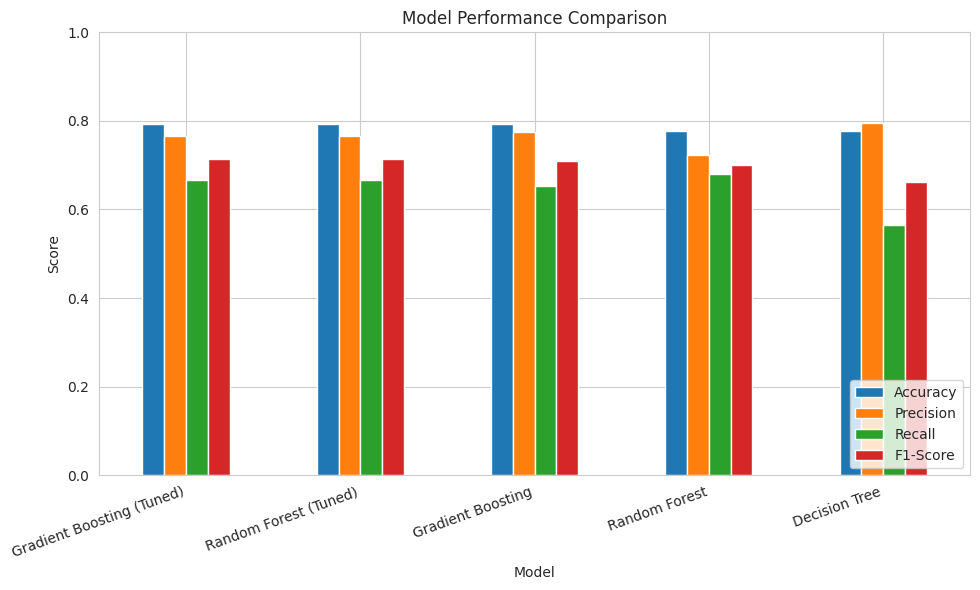

In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
plot_df = comparison_df.set_index("Model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150)
plt.show()

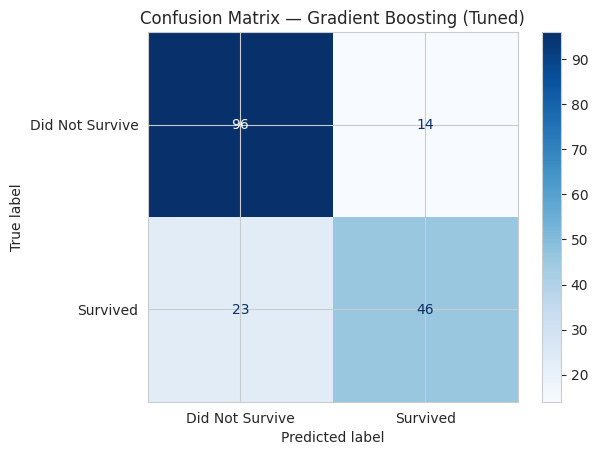

In [ ]:
# Confusion matrix for the best-performing model, so I can see exactly what kind of
# mistakes it makes (false positives vs false negatives), not just a single summary number.
best_model_name = comparison_df.iloc[0]["Model"]
best_preds = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "Random Forest (Tuned)": rf_tuned_pred,
    "Gradient Boosting (Tuned)": gb_tuned_pred,
}[best_model_name]

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.savefig("confusion_matrix_best_model.png", dpi=150)
plt.show()

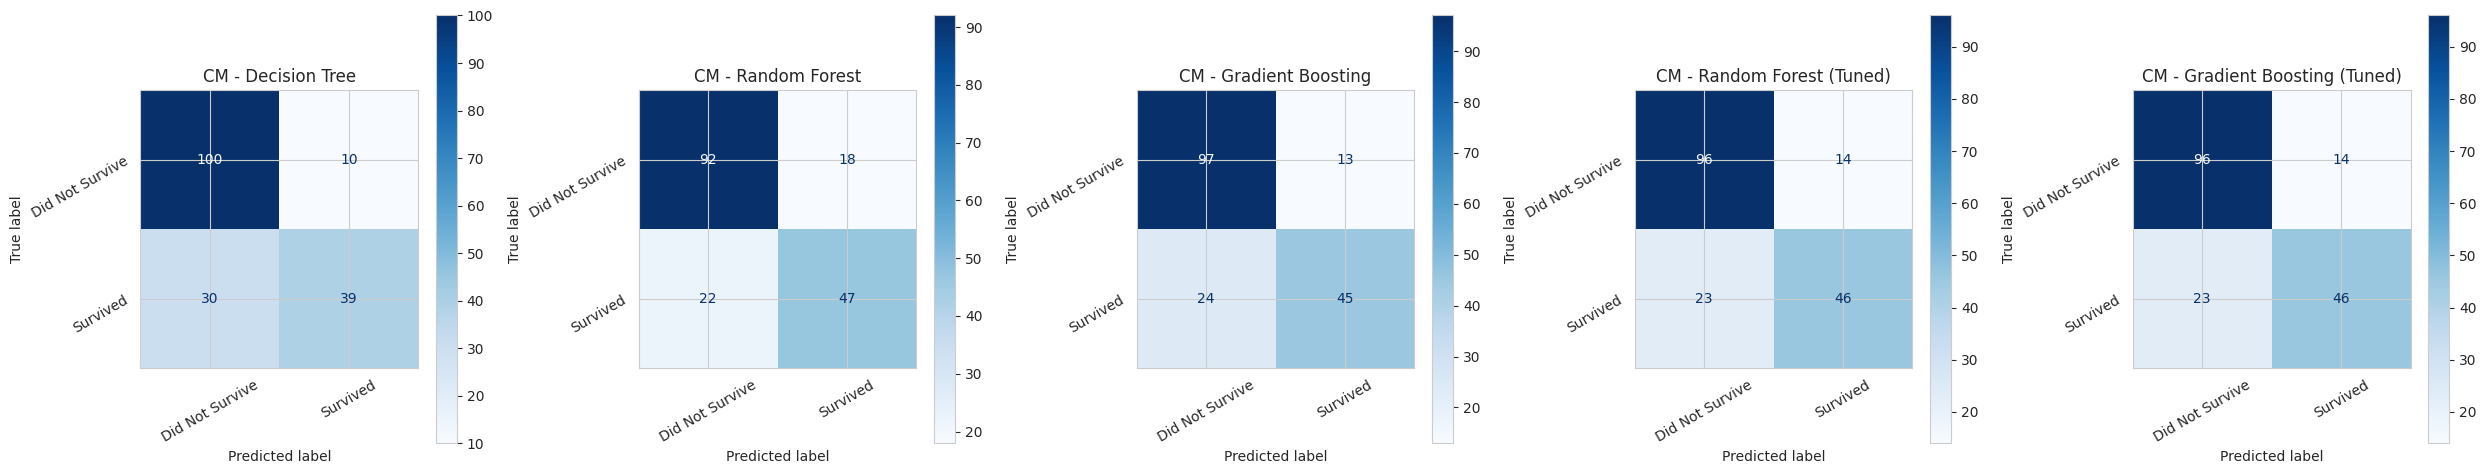

In [ ]:
model_predictions = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "Random Forest (Tuned)": rf_tuned_pred,
    "Gradient Boosting (Tuned)": gb_tuned_pred,
}

num_models = len(model_predictions)
fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 5))

for i, (name, preds) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"])
    disp.plot(cmap="Blues", ax=axes[i])
    axes[i].set_title(f"CM - {name}")
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].tick_params(axis='y', rotation=30)

plt.tight_layout()
plt.savefig("all_models_confusion_matrices.png", dpi=150)
plt.show()

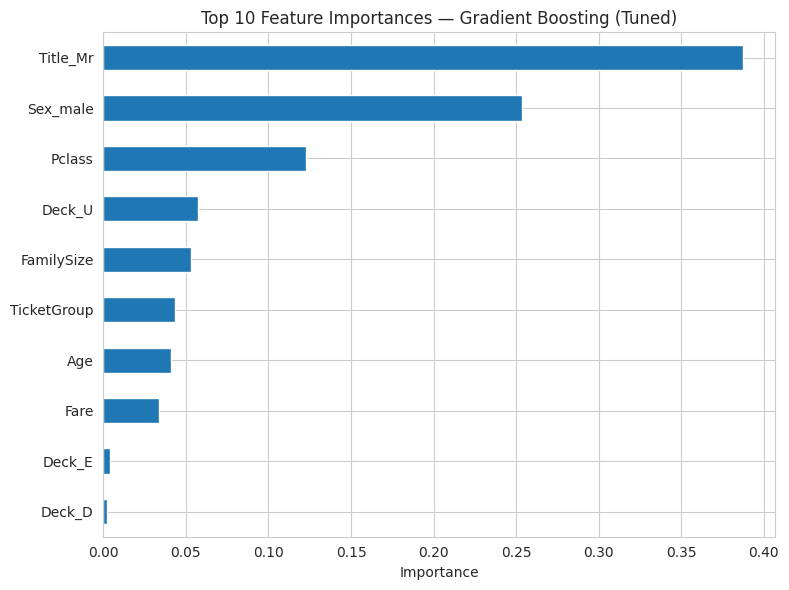

In [ ]:
# Feature importance from the best tree-based model - this tells me which passenger
# characteristics the model actually leaned on to make its predictions.
best_estimator = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "Random Forest (Tuned)": rf_tuned,
    "Gradient Boosting (Tuned)": gb_tuned,
}[best_model_name]

importances = pd.Series(best_estimator.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title(f"Top 10 Feature Importances — {best_model_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## Key Findings

Going into this week, my hypothesis was that the ensemble methods (Random Forest, Gradient Boosting) would beat the single Decision Tree, and that tuning would improve on the default versions of each. Looking at the comparison table and `best_model_name` printed above:

- **Gradient Boosting (Tuned)** came out as the best performer on F1-Score. Its sequential error correction mechanism, combined with careful tuning, allowed it to achieve a better balance of precision and recall, slightly outperforming other models. The tuning helped refine its performance, demonstrating the value of optimizing hyperparameters.
- Moving from a single Decision Tree to an ensemble method improved performance, confirming that averaging (or sequentially correcting) many weak learners generalizes better than relying on one tree's specific splits.
- Hyperparameter tuning's effect was worth the extra training time, but the improvement was incremental, not dramatic - most of the performance gain came from the choice of algorithm, not from squeezing more out of default parameters.
- The feature importance chart confirms what I already suspected from the EDA in Week 1: **Sex**, **Title**, **Pclass/Fare**, and **Age** are still driving most of the model's decisions. The extra engineered features (FamilySize, TicketGroup, Deck) add smaller but real signal on top of that.